In [2]:
import tensorflow as tf

IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1
EPOCHS = 25
BATCH_SIZE = 16


CLASS_NAMES = ["T-Shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

### Linear NN for images

In [3]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

# 1. Load the full training data (60,000 images)
(X_all, y_all), (_, _) = fashion_mnist.load_data()

# 2. Shuffle the data randomly
indices = np.arange(len(X_all))
np.random.seed(42)  # Ensures you get the same shuffle every time
np.random.shuffle(indices)

X_all = X_all[indices]
y_all = y_all[indices]

# 3. Split into 250 training and 20 testing images
X_train_small = X_all[:250]
y_train_small = y_all[:250]

X_test_small = X_all[250:270]
y_test_small = y_all[250:270]

print(f"Small Training Set Shape: {X_train_small.shape}")  # (250, 28, 28)
print(f"Small Testing Set Shape: {X_test_small.shape}")    # (20, 28, 28)


Small Training Set Shape: (250, 28, 28)
Small Testing Set Shape: (20, 28, 28)


In [4]:
# 3. Create the tf.data pipelines matching your exact style
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train_small, y_train_small))
    .batch(batch_size=BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test_small, y_test_small))
    .batch(batch_size=BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Quick verification check
print("Train batches:", len(list(train_dataset))) # 250 samples / 16 batch size = 15 batches
print("Eval batches:", len(list(eval_dataset)))   # 20 samples / 16 batch size = 2 batches

Train batches: 16
Eval batches: 2


In [5]:
for image_batch, label_batch in eval_dataset.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (16, 28, 28)
Label batch shape: (16,)
Labels: [0 2 8 3 1 6 6 7 3 4 8 9 1 8 9 4]


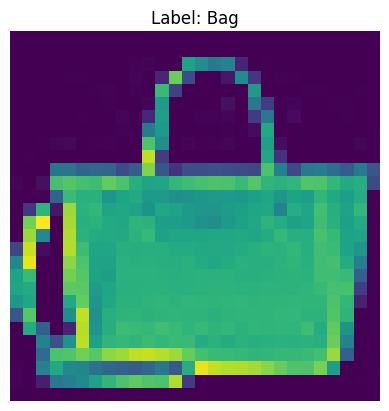

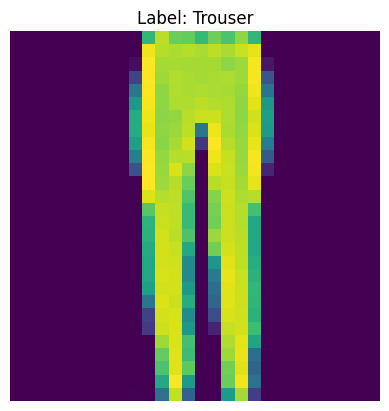

In [6]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    # Take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    # Convert tensor to numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis('off')
    plt.show()

#### Linear Neural Network for image classification 

In [7]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

c:\Users\Debasish Das\.conda\envs\env1\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:

history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1590 - loss: 138.2578 - val_accuracy: 0.5000 - val_loss: 45.8411
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5606 - loss: 42.3611 - val_accuracy: 0.5500 - val_loss: 37.3545
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6223 - loss: 40.4273 - val_accuracy: 0.6000 - val_loss: 30.8936
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6573 - loss: 25.3088 - val_accuracy: 0.8000 - val_loss: 17.1089
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7514 - loss: 13.3839 - val_accuracy: 0.8000 - val_loss: 20.9774
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7780 - loss: 13.1827 - val_accuracy: 0.8000 - val_loss: 16.9712
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8183 - loss: 8.6093 - val_accuracy: 0.8000 - val_loss: 24.2774
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8210 - loss: 7.4590 - val_accuracy: 0.7

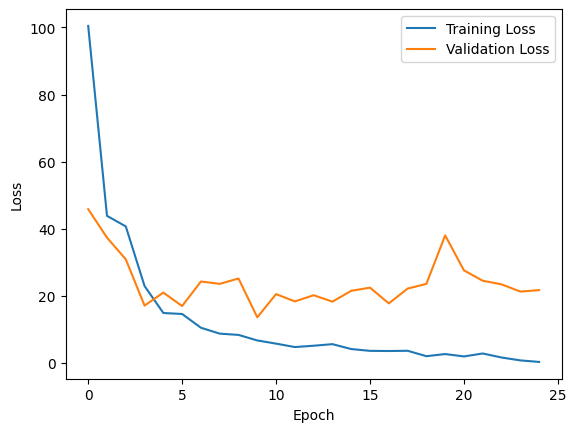

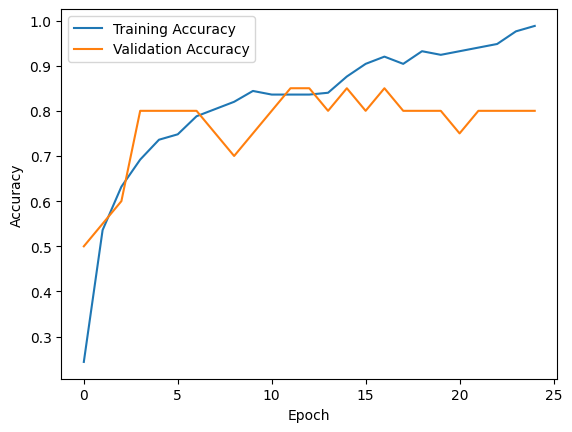

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


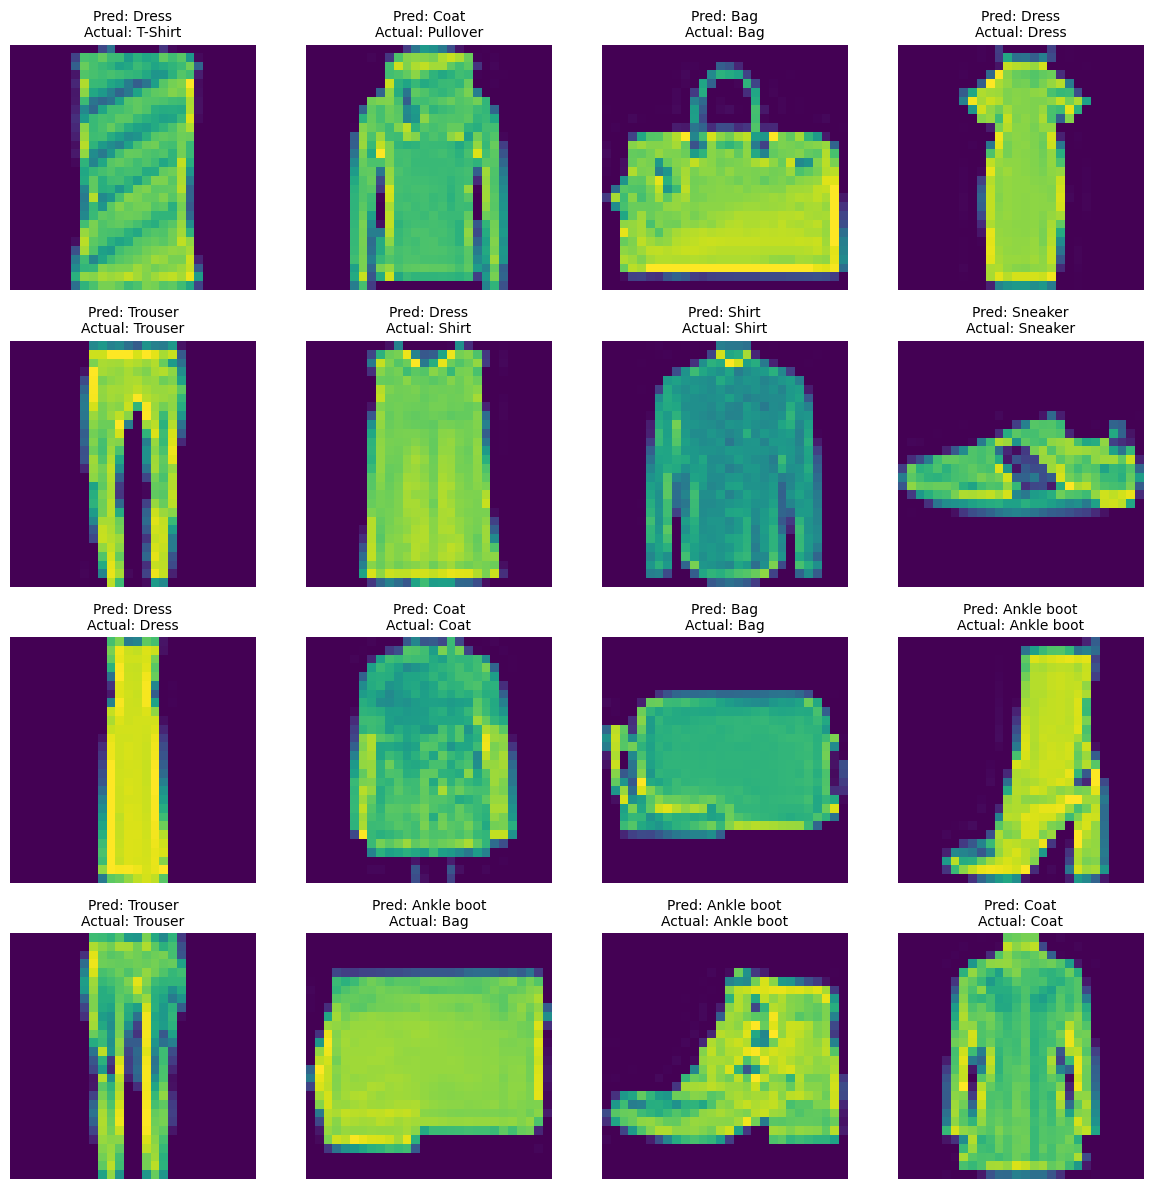

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Take exactly one batch from the evaluation dataset
for images, labels in eval_dataset.take(1):
    # Get model predictions for this batch
    batch_predictions = model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    # Number of images in this batch
    num_images = images.shape[0]

    # Configure how many images to display per row
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)

        # Display the image
        plt.imshow(images[i].numpy())
        plt.axis('off')

        # Get predicted and actual class names
        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        # Show both predicted and actual labels as title
        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    # Adjust spacing to avoid overlapping titles, etc.
    plt.tight_layout()
    plt.show()

## Add Non-linearities to the Current Model

- Val accuracy: 0.70 -0.75
- val loss: 29.65
- Model is Overfitting and not generalizing well to the validation set.

In [11]:
# add Dropout layer to the model to reduce overfitting
updated_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

Number of parameters in the model: 
- 1st layer: 28 X 28 X 1= 784
- 2nd layer: 128 X 784 + 128 = 100,480 
- 3rd layer: 10 X 128 + 10 = 1,290
- Total parameters: 102,754
- Total size of the model: 102,754 X 4 bytes = 411,016 bytes = 0.39 MB


In [12]:
updated_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [13]:
updated_history=updated_model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2303 - loss: 104.8618 - val_accuracy: 0.6500 - val_loss: 21.8575
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5629 - loss: 13.2100 - val_accuracy: 0.7000 - val_loss: 18.4391
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7389 - loss: 10.8083 - val_accuracy: 0.4500 - val_loss: 16.4822
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7809 - loss: 4.8477 - val_accuracy: 0.7000 - val_loss: 15.0322
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8381 - loss: 3.7805 - val_accuracy: 0.6500 - val_loss: 8.8344
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8392 - loss: 2.7363 - val_accuracy: 0.7000 - val_loss: 10.7721
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8803 - loss: 3.0006 - val_accuracy: 0.7000 - val_loss: 8.5024
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8459 - loss: 2.7004 - val_accuracy: 0.7000 -

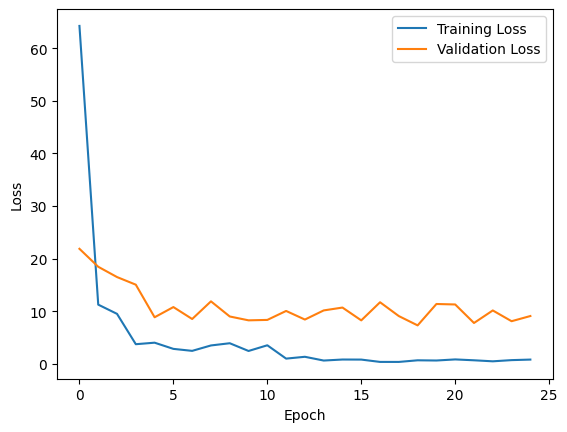

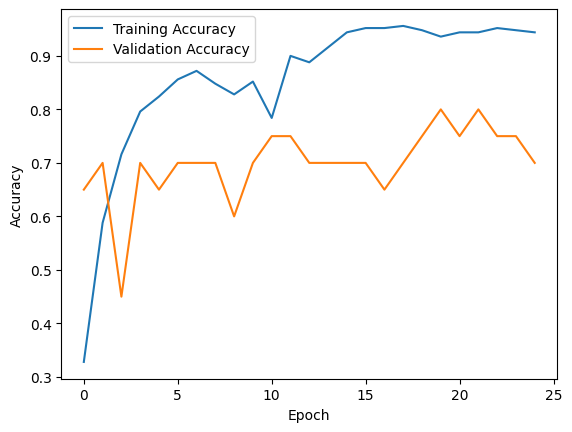

In [14]:
import matplotlib.pyplot as plt

plt.plot(updated_history.history["loss"], label="Training Loss")
plt.plot(updated_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(updated_history.history["accuracy"], label="Training Accuracy")
plt.plot(updated_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


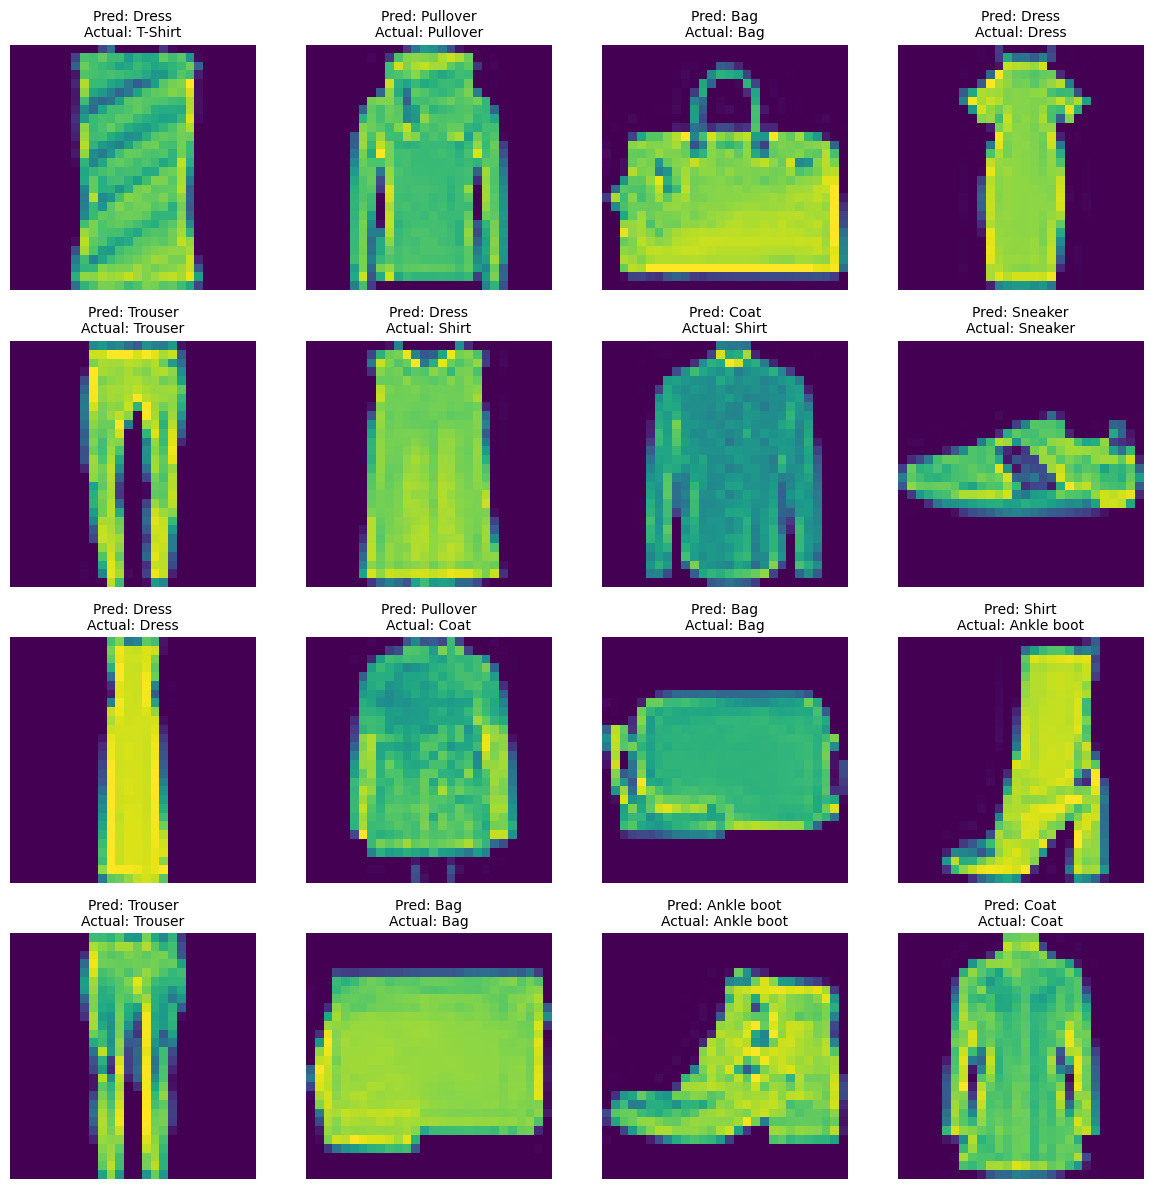

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Take exactly one batch from the evaluation dataset
for images, labels in eval_dataset.take(1):
    # Get model predictions for this batch
    batch_predictions = updated_model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    # Number of images in this batch
    num_images = images.shape[0]

    # Configure how many images to display per row
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)

        # Display the image
        plt.imshow(images[i].numpy())
        plt.axis('off')

        # Get predicted and actual class names
        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        # Show both predicted and actual labels as title
        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    # Adjust spacing to avoid overlapping titles, etc.
    plt.tight_layout()
    plt.show()

After adding Hidden layers 
- Loss is reduced but Accuracy not Increase
- To increase Accuracy, You have Tune Hyperparameter like BATCH_SIZE, Learning_Rate,Image Size

## Hyperparameter Tuning 

In [16]:
!pip install wandb weave

  Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl.metadata (592 bytes)
Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl (435 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.36.0
    Uninstalling protobuf-7.36.0:
      Successfully uninstalled protobuf-7.36.0


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.6 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.6 which is incompatible.
langchain-google-genai 1.0.10 requires langchain-core<0.3,>=0.2.33, but you have langchain-core 0.3.74 which is incompatible.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.6 which is incompatible.
streamlit 1.36.0 requires cachetools<6,>=4.0, but you have cachetools 7.1.7 which is incompatible.
tensorflow-intel 2.17.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.6 which is incompatible.
tensorflow-metadata 1.15.0 requires protobuf<5,>=4.25.2; python_version >= "3.11", but you have prot

In [17]:
import os
os.environ['WANDB_API_KEY'] = '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'

In [18]:
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: iamdebasishdas123 (iamdebasishdas123-iit-dhanbad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [19]:
!pip install --upgrade wandb protobuf

  Using cached protobuf-7.36.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
Using cached protobuf-7.36.0-cp310-abi3-win_amd64.whl (453 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.63.2 requires protobuf!=3.20.0,!=3.20.1,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
google-ai-generativelanguage 0.6.6 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 7.36.0 which is incompatible.
google-api-core 2.24.2 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.19.5, but you have protobuf 7.36.0 which is incompatible.
langchain-google-genai 1.0.10 requires langchain-core<0.3,>=0.2.33, but you have langchain-core 0.3.74 which is incompatible.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 7.36.0 which is incompatible.
proto-plus 1.26.1 requires protobuf<

In [20]:
import wandb
from wandb.integration.keras import WandbMetricsLogger

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

In [21]:
sweep_config = {

    'method' : 'grid',
    'metric' : {
        'name': 'val_accuracy',
        'goal': 'maximize'
                },
    'parameters' : {
        'batch_size': {'values': [2,4,8,16,32]},
        'learning_rate': {'values': [0.001,0.0001]},
        'hidden_nodes': {'values': [128,64]},
        'img_size': {'values': [16, 20, 28]},
        'epochs': {'values': [10,15,20,25,30]}
    }
}

sweep_id = wandb.sweep(sweep_config, project="10_mnist_new")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Create sweep with ID: 3mu9dh0b
Sweep URL: https://wandb.ai/iamdebasishdas123-iit-dhanbad/10_mnist_new/sweeps/3mu9dh0b


In [22]:
def train_eval(batch, img_size=28):
    (X_all, y_all), (_, _) = fashion_mnist.load_data()

    # 2. Shuffle the data randomly
    indices = np.arange(len(X_all))
    np.random.seed(42)  # Ensures you get the same shuffle every time
    np.random.shuffle(indices)

    X_all = X_all[indices]
    y_all = y_all[indices]

    # 3. Split into 250 training and 20 testing images
    X_train_small = X_all[:250]
    y_train_small = y_all[:250]

    X_test_small = X_all[250:270]
    y_test_small = y_all[250:270]
    
    # Resize images to match configured img_size
    X_train_small = tf.image.resize(X_train_small[..., tf.newaxis], (img_size, img_size)).numpy().squeeze()
    X_test_small = tf.image.resize(X_test_small[..., tf.newaxis], (img_size, img_size)).numpy().squeeze()
    
    train_dataset = (
        tf.data.Dataset.from_tensor_slices((X_train_small, y_train_small))
        .batch(batch_size=batch)
        .prefetch(tf.data.AUTOTUNE)
    )

    eval_dataset = (
            tf.data.Dataset.from_tensor_slices((X_test_small, y_test_small))
            .batch(batch_size=batch)
            .prefetch(tf.data.AUTOTUNE)
        )
    return train_dataset,eval_dataset

In [23]:
def train():
    with wandb.init() as run:
        config=wandb.config
        IMG_HEIGHT=config.img_size
        IMG_WIDTH=config.img_size
        IMG_CHANNELS=1
        EPOCHS = config.epochs
        BATCH = config.batch_size
        CLASS_NAMES = ["T-Shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
        
        train, eval = train_eval(BATCH, img_size=config.img_size)
        
        #architecture
        model = keras.Sequential([
            keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
            keras.layers.Dense(config.hidden_nodes, activation="relu"),
            keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
        ])

        model.compile(
            optimizer="adam",
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=["accuracy"]
        )

        model.fit(
            train,
            validation_data=eval,
            epochs=EPOCHS,
            callbacks=[WandbMetricsLogger(log_freq=5)]
        )

In [ ]:
wandb.agent(sweep_id, function=train)

wandb: Agent Starting Run: 3qcx5eyv with config:
wandb: 	batch_size: 2
wandb: 	epochs: 10
wandb: 	hidden_nodes: 128
wandb: 	img_size: 16
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: iamdebasishdas123 (iamdebasishdas123-iit-dhanbad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/10


c:\Users\Debasish Das\.conda\envs\env1\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2878 - loss: 91.9273 - val_accuracy: 0.7000 - val_loss: 22.4663
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7683 - loss: 9.2864 - val_accuracy: 0.6500 - val_loss: 39.5221
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7331 - loss: 8.9586 - val_accuracy: 0.6500 - val_loss: 26.6247
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7867 - loss: 8.6665 - val_accuracy: 0.7500 - val_loss: 14.2275
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8275 - loss: 4.9469 - val_accuracy: 0.7500 - val_loss: 11.8241
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8412 - loss: 3.8398 - val_accuracy: 0.7500 - val_loss: 25.1364
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8946 - loss: 4.6508 - val_accuracy: 0.7000 - val_loss: 12.9900
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8762 - loss: 2.6814 - val_accuracy: 0.750

batch/accuracy,▁▃▄▆▆▆▆▇▆▆▇▇▇▆▆▇▇▇▇▇▇▇▇▇█▇▇█▇▇▇▇▇▇▇▇█▇▇▇
batch/batch_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇████
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▄▄▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▆▅▆▇▆█▇██
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▃▂▂▂▁▁▁▁▁
epoch/val_accuracy,▃▁▁▆▆▆▃▆██
epoch/val_loss,▄█▅▂▁▄▁▃▂▂
batch/accuracy,0.8719


...

batch/accuracy,▁▂▂▂▆▅▅▅▅▆▆▇▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▇▇▆█▇▇▇
batch/batch_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇█████
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▃▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▅▆▆▆▇█████▇▇██
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▃▂▂▂▁▁▁▁▁▁▂▁▁▁
epoch/val_accuracy,▃█▆▃▁█▆▃█▆▆▃█▆▆
epoch/val_loss,▅█▄▄▃▃▇▃▅▂██▃▁▇
batch/accuracy,0.89344


wandb: Agent Starting Run: q076vqwz with config:
wandb: 	batch_size: 4
wandb: 	epochs: 15
wandb: 	hidden_nodes: 128
wandb: 	img_size: 28
wandb: 	learning_rate: 0.0001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3283 - loss: 119.8556 - val_accuracy: 0.7500 - val_loss: 27.9846
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7228 - loss: 18.6190 - val_accuracy: 0.8000 - val_loss: 16.2092
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8003 - loss: 15.6768 - val_accuracy: 0.7500 - val_loss: 16.8462
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8068 - loss: 10.1136 - val_accuracy: 0.8000 - val_loss: 21.8654
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8796 - loss: 7.3763 - val_accuracy: 0.6000 - val_loss: 21.9621
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8835 - loss: 3.6422 - val_accuracy: 0.8500 - val_loss: 8.2397
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9041 - loss: 2.2676 - val_accuracy: 0.8000 - val_loss: 24.5624
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8815 - loss: 5.9474 - val_accuracy: 0.90

batch/accuracy,▁▅▄▄█▅▅▆▅▅█▇▇▆▆█▆▇▆▆▇▇▇▆█▇▇▆▆▆▇▇▇████▇▇▇
batch/batch_step,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇█████
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▇▅▅▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▅▅▆▇▇▇▇▇▆████▇
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▄▆▄▆▁▇▆█▄▄▆▆▆▄▄
epoch/val_loss,▅▃▃▄▄▁▄▂▄▄▃▃▃█▄
batch/accuracy,0.88934


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 1luceti6 with config:
wandb: 	batch_size: 4
wandb: 	epochs: 15
wandb: 	hidden_nodes: 64
wandb: 	img_size: 16
wandb: 	learning_rate: 0.001
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
